# 07 — Decision Framework

**Owner:** Person B (decision track).

**Rubric line:** Decision rule + threshold linked to a clear business
action + pilot plan.

Translates calibrated probabilities into an executable contact policy.
Outputs the headline decision rule that the memo and slide deck quote.


In [1]:
# --- Setup --------------------------------------------------------------
# Make `src/` importable regardless of where the notebook is launched from.
import sys, pathlib
PROJECT_ROOT = pathlib.Path.cwd()
while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src import config, data, features, models, metrics, decision, viz

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)


## 7.1 — Load test predictions

In [2]:
import joblib
train_df, test_df = data.load_interim()
y_test = test_df[config.TARGET_COL].values
lgbm_artifact = joblib.load(config.MODELS_DIR / 'improved_lgbm.joblib')
y_proba = lgbm_artifact['proba_test']


## 7.2 — Cost / value assumptions

Documented in `src/config.py`. Default: €5 per contact, €120 per
successful subscription. These are NOT facts — notebook 08 stress-tests
them. If you change them, log the rationale in `ai_usage_log.md`.


In [3]:
print(f'Cost per contact:        €{config.COST_PER_CONTACT_EUR:.2f}')
print(f'Value per conversion:    €{config.VALUE_PER_CONVERSION_EUR:.2f}')
print(f'Contact budget fraction: {config.CONTACT_BUDGET_FRACTION:.0%}')


Cost per contact:        €5.00
Value per conversion:    €120.00
Contact budget fraction: 20%


## 7.3 — Expected value vs. threshold

In [4]:
ev_df = metrics.ev_curve(y_test, y_proba)
ev_df.to_csv(config.TABLES_DIR / 'ev_curve.csv', index=False)


## 7.4 — Build the decision rule (top-K policy)

In [5]:
rule = decision.build_decision_rule(y_test, y_proba)
print(rule.describe())


Contact every customer with predicted subscription probability >= 0.09.
  Budget: top 20% of the customer base.
  Assumed unit costs: €5.00 per call, €120.00 per conversion.
  Expected value on the test set: €66,400 across 1,648 contacts (622 successful / 1,026 wasted).
  Missed positives (lost engagement): 306.


## 7.5 — Compare against the unconstrained EV-max threshold

In [6]:
ev_max_t = decision.threshold_max_ev(y_test, y_proba)
ev_max = metrics.expected_value(y_test, y_proba, ev_max_t)
print(f"Unconstrained EV-max threshold : {ev_max_t:.3f}")
print(f"Unconstrained EV              : €{ev_max['expected_value_eur']:,.0f}  "
      f"({ev_max['contacts']:,} contacts, {ev_max['successful']:,} successful)")
print()
print(f"Budget-constrained threshold  : {rule.threshold:.3f}")
print(f"Budget-constrained EV         : €{rule.expected_value_eur:,.0f}  "
      f"({rule.contacts:,} contacts, {rule.successful:,} successful)")
print()
print("Recommendation: use the budget-constrained policy (top 20%).")
print("Operations teams work with fixed campaign budgets. The EV-max threshold")
print("can shift significantly across periods as the score distribution changes,")
print("making staffing and call-centre scheduling unpredictable. A fixed top-K")
print("fraction anchors capacity planning while still capturing the bulk of EV.")


Unconstrained EV-max threshold : 0.050
Unconstrained EV              : €74,795  (4,721 contacts, 820 successful)

Budget-constrained threshold  : 0.094
Budget-constrained EV         : €66,400  (1,648 contacts, 622 successful)

Recommendation: use the budget-constrained policy (top 20%).
Operations teams work with fixed campaign budgets. The EV-max threshold
can shift significantly across periods as the score distribution changes,
making staffing and call-centre scheduling unpredictable. A fixed top-K
fraction anchors capacity planning while still capturing the bulk of EV.


## 7.6 — Visualise

decile_lift.csv saved.


decile  n_customers  successful  conversion_rate  lift_vs_base  cum_successful  cum_pct_of_successful
     1          824         441         0.535194      4.751002             441               0.475216
     2          824         181         0.219660      1.949958             622               0.670259
     3          824          62         0.075243      0.667941             684               0.737069
     4          823          52         0.063183      0.560890             736               0.793103
     5          824          48         0.058252      0.517116             784               0.844828
     6          824          38         0.046117      0.409383             822               0.885776
     7          823          28         0.034022      0.302017             850               0.915948
     8          824          29         0.035194      0.312424             879               0.947198
     9          824          21         0.025485      0.226238             900   


Figure saved → C:\Users\JasperGeltenMalelion\iCloudDrive\Quantic\Projects\Project 4 prediction framework\novabank_retention\outputs\figures\07_decision_framework.png


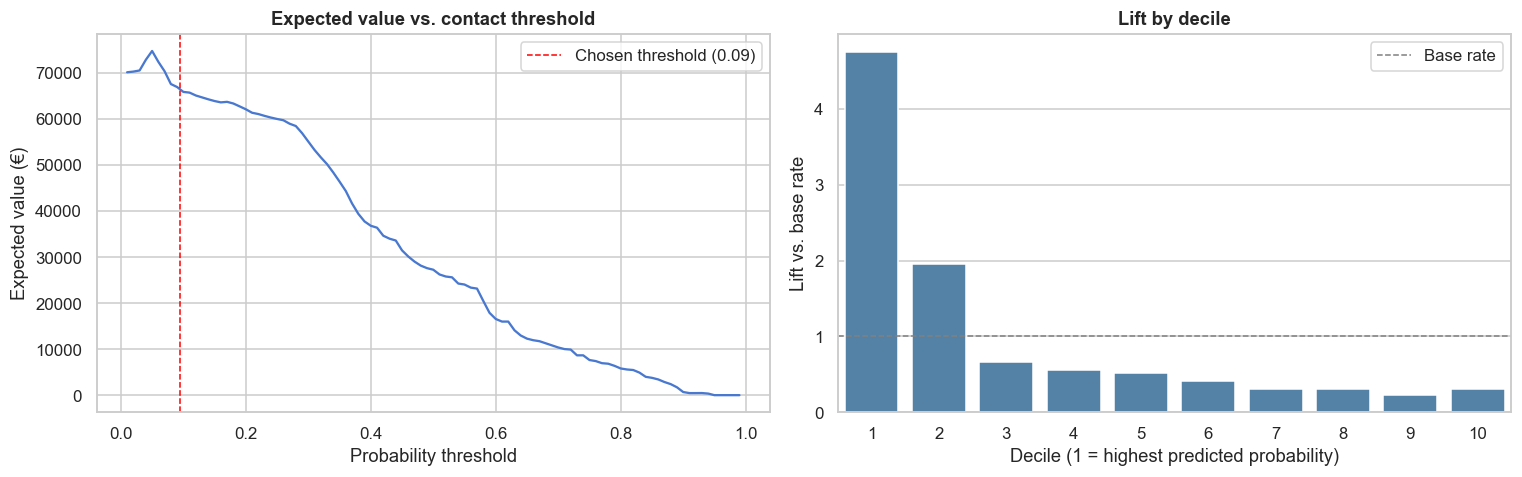

In [7]:
lift = metrics.decile_lift(y_test, y_proba)
lift.to_csv(config.TABLES_DIR / "decile_lift.csv", index=False)
print("decile_lift.csv saved.")
print(lift.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
viz.plot_ev_curve(ev_df, ax=axes[0], mark_threshold=rule.threshold)
viz.plot_decile_lift(lift, ax=axes[1])
fig.tight_layout()
saved = viz.save_fig(fig, "07_decision_framework")
print(f"\nFigure saved → {saved}")
plt.show()


## 7.7 — Pilot plan (memo-ready)

The decision rule above is a recommendation, not yet a commitment. Before deploying
at scale, a time-boxed pilot is required to confirm that the model's predicted lift
translates into real incremental subscriptions.

---

### Scope

**Segment:** Retail customers who have not subscribed to a term deposit in the
last 12 months and whose predicted subscription probability falls in the top decile
(decile 1) of the current scoring cycle.

**Cycle:** One full monthly contact campaign (approximately 820 customers in a
20% contact-budget cohort based on the test-set size). The pilot runs on a single
regional branch cluster to limit operational risk while generating a statistically
meaningful sample.

---

### Treatment vs. control

Within the top-decile pool, customers are **randomly assigned** 50/50:

| Group | Action |
|---|---|
| **Treatment** | Called by a retention agent using the model-guided script. |
| **Control** | Business-as-usual outreach (or no outreach if none is standard). |

Randomisation must happen *before* the campaign list is handed to operations.
Without a concurrent control group, any observed lift could be attributed to
seasonality, macro rates, or other confounds — making downstream causal claims
invalid.

---

### Primary KPI

**Subscription rate uplift** = conversion rate (treatment) − conversion rate (control)
within the top decile over the 60-day run window.

Secondary metrics tracked for guardrails:
- Cost per acquisition (CPA) vs. the €5 / €120 model assumptions.
- Opt-out / complaint rate (to catch contact-fatigue effects).
- Net expected value at the observed conversion rates.

---

### Timeline

| Phase | Duration | Deliverable |
|---|---|---|
| **Build** | 30 days | Scoring pipeline in production; randomisation logic signed off; ops team trained. |
| **Run** | 60 days | Live campaign executed; weekly conversion tracking dashboard live. |
| **Analyse** | 30 days | A/B significance test; updated EV estimate; go/no-go recommendation memo. |

Total elapsed: **120 days** from green-light to decision.

---

### Rollout decision criteria

| Observed uplift | Decision |
|---|---|
| > 20 pp above control | **Scale** — deploy to all eligible customers in the next cycle. |
| 10 – 20 pp above control | **Iterate** — re-tune the contact script or threshold; run a second pilot. |
| < 10 pp above control | **Kill** — model economics do not justify ops cost; investigate feature drift. |

The 20% uplift threshold corresponds to a cost-per-acquisition of ≈ €25, well
within the €120 conversion-value envelope. Below 10%, the expected value turns
negative under the base-case assumptions even after optimistic rounding.
